### Notebook 24

# **Multi-Channel Statistical Tests**

## **1. Foundation Models (Wilcoxon Tests)**

We perform **Wilcoxon signed-rank tests** on the results of the foundation models. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import scipy
import pingouin
from statsmodels.stats.contingency_tables import mcnemar

In [2]:
# Define the preprocessed data path. 
preprocessed_data_path = '../neuropolis-x1_preprocessed_data/'

# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [3]:
# Load the targets. 
with open(preprocessed_data_path + 'dict_targets.p', 'rb') as file:
    dict_targets = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_targets_classification_sequence.p', 'rb') as file:
    dict_targets_class = pickle.load(file)
with open(preprocessed_data_path + 'regression/dict_targets_regression_sequence.p', 'rb') as file:
    dict_targets_reg = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_targets_classification_basis.p', 'rb') as file:
    dict_targets_foundation_models = pickle.load(file)

In [4]:
# Define the list of subjects, removing sub-xp102 who has a missing condition. 
subjects = ['sub-xp1' + str(x).zfill(2) for x in range(1, 11)]
subjects.remove('sub-xp102')
subject = subjects[0]

# Retrieve and display the brain region names and the number of brain regions. 
brain_regions = list(dict_targets[subject]['eegfmriNF'].keys())
print(brain_regions)
print(len(brain_regions), 'brain regions')

['Background', 'Frontal Pole', 'Insular Cortex', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Temporal Pole', 'Superior Temporal Gyrus, anterior division', 'Superior Temporal Gyrus, posterior division', 'Middle Temporal Gyrus, anterior division', 'Middle Temporal Gyrus, posterior division', 'Middle Temporal Gyrus, temporooccipital part', 'Inferior Temporal Gyrus, anterior division', 'Inferior Temporal Gyrus, posterior division', 'Inferior Temporal Gyrus, temporooccipital part', 'Postcentral Gyrus', 'Superior Parietal Lobule', 'Supramarginal Gyrus, anterior division', 'Supramarginal Gyrus, posterior division', 'Angular Gyrus', 'Lateral Occipital Cortex, superior division', 'Lateral Occipital Cortex, inferior division', 'Intracalcarine Cortex', 'Frontal Medial Cortex', 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)', 'Subcallosal Cortex', 'Paracingulate

In [5]:
# Define a function to perform a Wilcoxon signed-rank test. 
def wilcoxon_test(df, score_type):

    # Compute the mean and standard deviation of the model and the baseline. 
    mean_model_score = df['model_' + score_type].mean()
    mean_baseline_score = df['baseline_' + score_type].mean()
    std_model_score = df['model_' + score_type].std()
    std_baseline_score = df['baseline_' + score_type].std()

    # Perform the Wilcoxon signed-rank test using SciPy. 
    x = df['model_' + score_type].astype(float).values
    y = df['baseline_' + score_type].astype(float).values
    if score_type == 'accuracy':
        wilcoxon_stat, p_value = scipy.stats.wilcoxon(x, y, alternative = 'greater')
    elif score_type == 'MAE':
        wilcoxon_stat, p_value = scipy.stats.wilcoxon(x, y, alternative = 'less')

    # Compute the confidence interval of the mean. 
    res = scipy.stats.bootstrap((df['model_' + score_type],), np.mean, confidence_level = 0.95)
    ci_low, ci_high = res.confidence_interval

    # Store the statistics in a DataFrame. 
    statistics_scipy = pd.DataFrame([{
        'N': len(df),
        'mean_model_' + score_type: mean_model_score,
        'mean_baseline_' + score_type: mean_baseline_score,
        'std_model_' + score_type: std_model_score,
        'std_baseline_' + score_type: std_baseline_score,
        'wilcoxon_stat': wilcoxon_stat,
        'p_value': p_value,
        'ci_low': ci_low, 
        'ci_high': ci_high
    }])

    # Perform the same test using Pingouin to obtain the RBC (Rank-Biserial Correlation) and CLES (Common Language Effect Size). 
    if score_type == 'accuracy':
        statistics_pingouin = pingouin.wilcoxon(x, y, alternative = 'greater')
    elif score_type == 'MAE':
        statistics_pingouin = pingouin.wilcoxon(y, x, alternative = 'greater') # Invert x and y for MAE to get the correct effect size direction. 
    
    # Return the statistics. 
    return statistics_scipy, statistics_pingouin

In [6]:
# Define a function to create a summary DataFrame. 
def create_summary_df(model_names, score_type):
    
    # Create the summary DataFrame. 
    df_summary = pd.DataFrame(index = model_names, 
                              columns = ['N', 
                                         'mean model ' + score_type, 
                                         'mean baseline ' + score_type, 
                                         'STD model ' + score_type,
                                         'STD baseline ' + score_type,
                                         'Wilcoxon W statistic', 
                                         'p-value', 
                                         'CI (lower)',
                                         'CI (upper)', 
                                         'RBC', 
                                         'CLES'])
    
    return df_summary

In [7]:
# Define a function to store statistics in the summary DataFrame. 
def store_statistics_in_summary_df(df_summary, model_names, model_index, statistics_scipy, statistics_pingouin, score_type):

    # Store the statistics in the summary DataFrame. 
    df_summary.loc[model_names[model_index], 'N'] = statistics_scipy['N'].values[0]
    df_summary.loc[model_names[model_index], 'mean model ' + score_type] = statistics_scipy['mean_model_' + score_type].values[0]
    df_summary.loc[model_names[model_index], 'mean baseline ' + score_type] = statistics_scipy['mean_baseline_' + score_type].values[0]
    df_summary.loc[model_names[model_index], 'STD model ' + score_type] = statistics_scipy['std_model_' + score_type].values[0]
    df_summary.loc[model_names[model_index], 'STD baseline ' + score_type] = statistics_scipy['std_baseline_' + score_type].values[0]
    df_summary.loc[model_names[model_index], 'Wilcoxon W statistic'] = statistics_scipy['wilcoxon_stat'].values[0]
    df_summary.loc[model_names[model_index], 'p-value'] = statistics_scipy['p_value'].values[0]
    df_summary.loc[model_names[model_index], 'CI (lower)'] = statistics_scipy['ci_low'].values[0]
    df_summary.loc[model_names[model_index], 'CI (upper)'] = statistics_scipy['ci_high'].values[0]
    df_summary.loc[model_names[model_index], 'RBC'] = statistics_pingouin['RBC'].values[0]
    df_summary.loc[model_names[model_index], 'CLES'] = statistics_pingouin['CLES'].values[0]

    # Ensure the p-value column is numeric, then format it in scientific notation. 
    df_summary['p-value'] = pd.to_numeric(df_summary['p-value'], errors = 'coerce')
    df_summary['p-value'] = df_summary['p-value'].apply(lambda x: f'{x:.2e}')

    return df_summary

In [8]:
# Load the foundation models results. 
with open(results_path + 'classification/dict_predictions_gemma.p', 'rb') as file:
    dict_predictions_gemma = pickle.load(file)
with open(results_path + 'multi-channel/dict_predictions_gemma_5_channels.p', 'rb') as file:
    dict_predictions_gemma_5_channels = pickle.load(file)

# Load the brain regions. 
with open(results_path + 'brain_regions_large_language_models.p', 'rb') as file:
    dict_brain_regions_large_language_models = pickle.load(file)
with open(results_path + 'multi-channel/brain_regions_multi-channel_large_language_models.p', 'rb') as file:
    dict_brain_regions_multi_channel_large_language_models = pickle.load(file)

# Load the fMRI scans. 
with open(results_path + 'fmri_scans_large_language_models.p', 'rb') as file:
    dict_fmri_scans_large_language_models = pickle.load(file)
with open(results_path + 'multi-channel/fmri_scans_multi-channel_large_language_models.p', 'rb') as file:
    dict_fmri_scans_multi_channel_large_language_models = pickle.load(file)

# Load the FLOPs. 
with open(results_path + 'flops_large_language_models.p', 'rb') as file:
    dict_flops_large_language_models = pickle.load(file)
with open(results_path + 'multi-channel/flops_multi-channel_large_language_models.p', 'rb') as file:
    dict_flops_multi_channel_large_language_models = pickle.load(file)

In [9]:
# Define the foundation models. 
model_names = ['Gemma', 'Gemma 5-Channel']
list_dict_predictions = [dict_predictions_gemma, 
                         dict_predictions_gemma_5_channels]

# Define the brain regions. 
list_brain_regions = [dict_brain_regions_large_language_models['Large Language Models: Gemma'],
                      dict_brain_regions_multi_channel_large_language_models['Large Language Models: Gemma 5 Channels']]

# Define the fMRI scans indexes. 
list_fmri_scans_indexes = [dict_fmri_scans_large_language_models['Large Language Models: Gemma'],
                           dict_fmri_scans_multi_channel_large_language_models['Large Language Models: Gemma 5 Channels']]

In [10]:
# Define a function to create a Pandas DataFrame of predictions values. 
def create_df_predictions_values(dict_predictions):

    # Define a list to store the predictions. 
    list_pred = []

    # Iterate through all brain regions and subjects. 
    for brain_region in dict_predictions.keys():
        for subject in subjects:
            list_pred.append(dict_predictions[brain_region][subject].flatten())

    # Flatten the predictions for all brain regions and subjects. 
    list_pred = np.array(list_pred).flatten()

    # Transform into a Pandas DataFrame. 
    df_pred = pd.DataFrame(list_pred, columns = ['predictions'])

    return df_pred['predictions']

In [11]:
# Create a Pandas DataFrame to store the predictions count values. 
df_predictions_count_values = pd.DataFrame()

# Iterate through all models. 
for dict_predictions in list_dict_predictions:

    # Count the values in the predictions. 
    df_predictions_values = create_df_predictions_values(dict_predictions)
    df_predictions_count_values = pd.concat([df_predictions_count_values, df_predictions_values.value_counts()], axis = 1)

# Change the row names. 0 = decreasing, 1 = increasing, -1 = ambiguous. 
df_predictions_count_values = df_predictions_count_values.rename(index = {0: 'decreasing', 1: 'increasing', -1: 'ambiguous'})

# Change the column names, replacing them by the names of the models. 
df_predictions_count_values.columns = model_names

# Display the DataFrame. 
df_predictions_count_values

,Gemma,Gemma 5-Channel
decreasing,1041,866
increasing,345,461
ambiguous,54,113


In [12]:
# Compute the proportion of decreasing and increasing predictions, excluding the ambiguous predictions. 
df_predictions_count_values_without_ambiguous = df_predictions_count_values.drop(index = 'ambiguous')
df_predictions_count_values_proportion = df_predictions_count_values_without_ambiguous.div(df_predictions_count_values_without_ambiguous.sum(axis = 0), axis = 1)
df_predictions_count_values_proportion

,Gemma,Gemma 5-Channel
decreasing,0.751082,0.6526
increasing,0.248918,0.3474


In [13]:
# Define a function to create the DataFrame for the statistical tests. 
def create_df_foundation_models(dict_targets, dict_predictions, brain_region_indexes, fmri_scans_indexes):
    
    # Define a Pandas DataFrames and two lists to store the results. 
    df = pd.DataFrame(columns = ['subject', 'brain_region', 'model_accuracy', 'baseline_accuracy'])
    list_targets = []
    list_predictions = []
    counter = 0

    # Iterate through all subjects. 
    for subject in subjects:

        # Iterate through all brain regions. 
        for brain_region_index in brain_region_indexes:
            
            # Fill the DataFrame with the subject and brain region. 
            df.loc[counter, 'subject'] = subject
            df.loc[counter, 'brain_region'] = brain_regions[brain_region_index]

            # Retrieve the targets and predictions values for the current subject and brain region. 
            targets_values = dict_targets[subject]['eegfmriNF'][fmri_scans_indexes, brain_region_index]
            predictions_values = dict_predictions[brain_regions[brain_region_index]][subject]

            # Add the targets and predictions to the lists. 
            list_targets.append(targets_values)
            list_predictions.append(predictions_values)

            # Remove the cases where the prediction is -1. 
            selected_predictions = predictions_values != -1
            targets_values = targets_values[selected_predictions]
            predictions_values = predictions_values[selected_predictions]

            # Compute the accuracy and fill in the DataFrame with the model score. 
            model_score = np.mean(targets_values == predictions_values)
            df.loc[counter, 'model_accuracy'] = model_score

            # Define the values and compute the targets distribution. 
            values = [0, 1]
            targets_distribution = [np.sum(targets_values == 0) / len(targets_values), 
                                    np.sum(targets_values == 1) / len(targets_values)]

            # Define the number of iterations. 
            iterations = 1000
            baseline_score = 0

            # Compute the baseline score using random sampling. 
            for i in range(iterations):
                samples = np.random.choice(values, size = len(targets_values), p = targets_distribution)
                baseline_score += np.mean(targets_values == samples)

            # Compute the mean baseline score. 
            baseline_score /= iterations

            # Fill in the DataFrame with the baseline score. 
            df.loc[counter, 'baseline_accuracy'] = baseline_score

            # Increment. 
            counter += 1

    return df, list_targets, list_predictions

In [14]:
# Create a function to retrieve foundation model elements. 
def retrieve_foundation_model_elements(model_index, list_dict_predictions, list_brain_regions, list_fmri_scans_indexes):

    # Retrieve the foundation model elements. 
    dict_predictions = list_dict_predictions[model_index]
    brain_region_indexes = [brain_regions.index(region) for region in list_brain_regions[model_index]]
    fmri_scans_indexes = list_fmri_scans_indexes[model_index]

    return dict_predictions, brain_region_indexes, fmri_scans_indexes

In [15]:
# Example: Create and display the DataFrame for the Gemma model. 
model_index = 0
dict_predictions, brain_region_indexes, fmri_scans_indexes = retrieve_foundation_model_elements(model_index, 
                                                                                                list_dict_predictions,
                                                                                                list_brain_regions,
                                                                                                list_fmri_scans_indexes)

# Create and display the DataFrame. 
df_gemma, _, _ = create_df_foundation_models(dict_targets_foundation_models, 
                                             dict_predictions, 
                                             brain_region_indexes, 
                                             fmri_scans_indexes)
df_gemma

,subject,brain_region,model_accuracy,baseline_accuracy
0,sub-xp101,Frontal Pole,0.35,0.5112
1,sub-xp101,Insular Cortex,0.65,0.50345
2,sub-xp101,"Inferior Frontal Gyrus, pars triangularis",0.55,0.5102
3,sub-xp101,Precentral Gyrus,0.529412,0.582059
4,sub-xp101,"Superior Temporal Gyrus, posterior division",0.4,0.50265
...,...,...,...,...
67,sub-xp110,Precentral Gyrus,0.45,0.51775
68,sub-xp110,"Superior Temporal Gyrus, posterior division",0.45,0.50255
69,sub-xp110,Superior Parietal Lobule,0.6,0.5026
70,sub-xp110,Angular Gyrus,0.210526,0.511474


In [16]:
# Perform Wilcoxon signed-rank test. 
statistics_scipy_gemma, statistics_pingouin_gemma = wilcoxon_test(df_gemma, 'accuracy')

In [17]:
# Display the SciPy statistics. 
statistics_scipy_gemma

,N,mean_model_accuracy,mean_baseline_accuracy,std_model_accuracy,std_baseline_accuracy,wilcoxon_stat,p_value,ci_low,ci_high
0,72,0.534141,0.528255,0.105855,0.037643,1483.0,0.171469,0.508918,0.557384


In [18]:
# Display the Pingouin statistics. 
statistics_pingouin_gemma

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1483.0,greater,0.172184,0.128615,0.556327


In [19]:
# Define a function to perform a Wilcoxon signed-rank test on a series of models. 
def run_wilcoxon_tests_foundation_models(model_names, dict_targets, list_dict_predictions, list_brain_regions, list_fmri_scans_indexes):

    # Create a summary DataFrame to store the statistics for all models. 
    df_summary = create_summary_df(model_names, 'accuracy')

    # Iterate through all models. 
    for model_index in range(len(model_names)):

        # Retrieve the predictions, brain region indexes, and fMRI scans indexes. 
        dict_predictions, brain_region_indexes, fmri_scans_indexes = retrieve_foundation_model_elements(model_index, 
                                                                                                        list_dict_predictions,
                                                                                                        list_brain_regions,
                                                                                                        list_fmri_scans_indexes)

        # Create the DataFrame and perform the Wilcoxon signed-rank test. 
        df, _, _ = create_df_foundation_models(dict_targets, dict_predictions, brain_region_indexes, fmri_scans_indexes)
        statistics_scipy, statistics_pingouin = wilcoxon_test(df, 'accuracy')

        # Store the statistics in the summary DataFrame. 
        df_summary = store_statistics_in_summary_df(df_summary, model_names, model_index, statistics_scipy, statistics_pingouin, 'accuracy')
        
    # Return the summary DataFrame. 
    return df_summary

In [20]:
# Run the Wilcoxon signed-rank tests for all models. 
df_summary_foundation_models = run_wilcoxon_tests_foundation_models(model_names, 
                                                                    dict_targets_foundation_models, 
                                                                    list_dict_predictions, 
                                                                    list_brain_regions,
                                                                    list_fmri_scans_indexes)
df_summary_foundation_models

,N,mean model accuracy,mean baseline accuracy,STD model accuracy,STD baseline accuracy,Wilcoxon W statistic,p-value,CI (lower),CI (upper),RBC,CLES
Gemma,72,0.534141,0.528481,0.105855,0.037478,1467.0,1.95e-01,0.508785,0.557637,0.116438,0.550154
Gemma 5-Channel,72,0.50252,0.530447,0.117832,0.040948,986.0,9.67e-01,0.475998,0.529573,-0.249619,0.38696


In [21]:
# Store the FLOPs in a DataFrame. 
df_flops_foundation_models = pd.DataFrame({
    'FLOPs for classification task': {
        'Gemma': dict_flops_large_language_models['Large Language Models: Gemma'],
        'Gemma 5-Channel': dict_flops_multi_channel_large_language_models['Large Language Models: Gemma 5 Channels'],
    }
})

# Display the DataFrame. 
df_flops_foundation_models

,FLOPs for classification task
Gemma,2998372810112
Gemma 5-Channel,6650270644224


In [22]:
# Retrieve the predictions, brain region indexes, and fMRI scans indexes for the Gemma model with 5 channels. 
model_index = 1
print('First model:', model_names[model_index])
dict_predictions, brain_region_indexes, fmri_scans_indexes = retrieve_foundation_model_elements(model_index, 
                                                                                                list_dict_predictions,
                                                                                                list_brain_regions,
                                                                                                list_fmri_scans_indexes)

# Create the DataFrame for Gemma with 5 channels. 
df_gemma_5_channels, _, _ = create_df_foundation_models(dict_targets_foundation_models, 
                                                        dict_predictions, 
                                                        brain_region_indexes, 
                                                        fmri_scans_indexes)

# Retrieve the predictions, brain region indexes, and fMRI scans indexes for the Gemma model with 1 channel. 
model_index = 0
print('Second model:', model_names[model_index])
dict_predictions, brain_region_indexes, fmri_scans_indexes = retrieve_foundation_model_elements(model_index, 
                                                                                                list_dict_predictions,
                                                                                                list_brain_regions,
                                                                                                list_fmri_scans_indexes)

# Create the DataFrame for Gemma with 1 channel. 
df_gemma_1_channel, _, _ = create_df_foundation_models(dict_targets_foundation_models, 
                                                       dict_predictions, 
                                                       brain_region_indexes, 
                                                       fmri_scans_indexes)

# Use the model accuracy with 5 channels as the baseline for the model with 1 channel. 
df_gemma_1_channel['baseline_accuracy'] = df_gemma_5_channels['model_accuracy']
df_gemma_1_channel.head()

First model: Gemma 5-Channel
Second model: Gemma


,subject,brain_region,model_accuracy,baseline_accuracy
0,sub-xp101,Frontal Pole,0.35,0.5
1,sub-xp101,Insular Cortex,0.65,0.35
2,sub-xp101,"Inferior Frontal Gyrus, pars triangularis",0.55,0.722222
3,sub-xp101,Precentral Gyrus,0.529412,0.5
4,sub-xp101,"Superior Temporal Gyrus, posterior division",0.4,0.5


In [23]:
# Perform Wilcoxon signed-rank test. 
statistics_scipy_gemma_1_channel, statistics_pingouin_gemma_1_channel = wilcoxon_test(df_gemma_1_channel, 'accuracy')

In [24]:
# Create a summary DataFrame to store the statistics. 
df_summary_wilcoxon_multi_channel = create_summary_df(['Gemma 1 Channel vs. Gemma 5 Channels'], 'accuracy')

# Store the statistics in the summary DataFrame. 
df_summary_wilcoxon_multi_channel = store_statistics_in_summary_df(df_summary_wilcoxon_multi_channel, 
                                                                ['Gemma 1 Channel vs. Gemma 5 Channels'], 
                                                                0, 
                                                                statistics_scipy_gemma_1_channel, 
                                                                statistics_pingouin_gemma_1_channel, 
                                                                'accuracy')
df_summary_wilcoxon_multi_channel

,N,mean model accuracy,mean baseline accuracy,STD model accuracy,STD baseline accuracy,Wilcoxon W statistic,p-value,CI (lower),CI (upper),RBC,CLES
Gemma 1 Channel vs. Gemma 5 Channels,72,0.534141,0.50252,0.105855,0.117832,1557.5,1.82e-02,0.509254,0.558101,0.289855,0.592496


In [25]:
# Define a function to retrieve 1-channel vs. 5-channel elements. 
def retrieve_1_channel_vs_5_channel_elements(model_index, list_dict_predictions, list_brain_regions, list_fmri_scans_indexes):
    
    # Retrieve the predictions, brain region indexes, and fMRI scans indexes. 
    dict_predictions, brain_region_indexes, fmri_scans_indexes = retrieve_foundation_model_elements(model_index, 
                                                                                                    list_dict_predictions,
                                                                                                    list_brain_regions,
                                                                                                    list_fmri_scans_indexes)
    
    # Retrieve the lists of targets and predictions. 
    _, list_targets, list_predictions = create_df_foundation_models(dict_targets_foundation_models, dict_predictions, brain_region_indexes, fmri_scans_indexes)

    # Flatten the lists of targets and predictions. 
    targets_values = np.array(list_targets).flatten()
    predictions_values = np.array(list_predictions).flatten()

    # Detect the cases where the prediction is not equal to -1. 
    selected_predictions = predictions_values != -1

    # Return the targets values, predictions values, and the selected predictions. 
    return targets_values, predictions_values, selected_predictions

In [26]:
# Return the targets values, predictions values, and the selected predictions for 1-channel vs. 5-channel. 
targets_values, predictions_values_5_channel, selected_predictions_5_channel = retrieve_1_channel_vs_5_channel_elements(1,
                                                                                                                        list_dict_predictions,
                                                                                                                        list_brain_regions,
                                                                                                                        list_fmri_scans_indexes)
targets_values, predictions_values_1_channel, selected_predictions_1_channel = retrieve_1_channel_vs_5_channel_elements(0,
                                                                                                                        list_dict_predictions,
                                                                                                                        list_brain_regions,
                                                                                                                        list_fmri_scans_indexes)

# Remove the cases where the prediction is -1 for either one of the two models. 
selected_predictions = selected_predictions_5_channel * selected_predictions_1_channel
targets_values = targets_values[selected_predictions]
predictions_values_5_channel = predictions_values_5_channel[selected_predictions]
predictions_values_1_channel = predictions_values_1_channel[selected_predictions]

# Determine the correctness of each model. 
_5_channel_correct = predictions_values_5_channel == targets_values
_1_channel_correct = predictions_values_1_channel == targets_values

# Create the 2x2 contingency table. 
a = np.sum(_1_channel_correct & _5_channel_correct)
b = np.sum(_1_channel_correct & ~_5_channel_correct)
c = np.sum(~_1_channel_correct & _5_channel_correct)
d = np.sum(~_1_channel_correct & ~_5_channel_correct)
contingency_table = [[a, b],
                     [c, d]]

# Perform McNemar's test. 
result = mcnemar(contingency_table)

# Store the results in a DataFrame. 
df_summary_mcnemar_multi_channel = pd.DataFrame(columns = ['N', 
                                                 'accuracy with 1 channel', 
                                                 'accuracy with 5 channels', 
                                                 'p-value'])
df_summary_mcnemar_multi_channel.loc['Gemma 1 Channel vs. Gemma 5 Channels', 'N'] = len(targets_values)
df_summary_mcnemar_multi_channel.loc['Gemma 1 Channel vs. Gemma 5 Channels', 'accuracy with 1 channel'] = np.mean(targets_values == predictions_values_1_channel)
df_summary_mcnemar_multi_channel.loc['Gemma 1 Channel vs. Gemma 5 Channels', 'accuracy with 5 channels'] = np.mean(targets_values == predictions_values_5_channel)
df_summary_mcnemar_multi_channel.loc['Gemma 1 Channel vs. Gemma 5 Channels', 'p-value'] = result.pvalue

# Display the summary DataFrame. 
df_summary_mcnemar_multi_channel

,N,accuracy with 1 channel,accuracy with 5 channels,p-value
Gemma 1 Channel vs. Gemma 5 Channels,1276,0.541536,0.499216,0.021238


## **4. Foundation Models (McNemar’s Tests)**

We perform **McNemar’s tests** on the results of the foundation models. 

In [27]:
# Define a function to perform a McNemar's test on a series of models. 
def run_mcnemars_tests_foundation_models(model_names, dict_targets, list_dict_predictions, list_brain_regions, list_fmri_scans_indexes):
    
    # Create a summary DataFrame and a dictionary to store the statistics for all models. 
    df_summary = pd.DataFrame(columns = ['N', 
                                         'model accuracy', 
                                         'baseline accuracy', 
                                         'combined statistic', 
                                         'combined p-value', 
                                         'median p-value', 
                                         'proportion p-value < 0.05'])
    dict_mcnemars_p_values = dict()

    # Iterate through all models. 
    for model_index in range(len(model_names)):

        # Retrieve the predictions, brain region indexes, and fMRI scans indexes. 
        dict_predictions, brain_region_indexes, fmri_scans_indexes = retrieve_foundation_model_elements(model_index, 
                                                                                                        list_dict_predictions,
                                                                                                        list_brain_regions,
                                                                                                        list_fmri_scans_indexes)

        # Retrieve the lists of targets and predictions. 
        _, list_targets, list_predictions = create_df_foundation_models(dict_targets, dict_predictions, brain_region_indexes, fmri_scans_indexes)

        # Flatten the lists of targets and predictions. 
        targets_values = np.array(list_targets).flatten()
        predictions_values = np.array(list_predictions).flatten()

        # Remove the cases where the prediction is -1. 
        selected_predictions = predictions_values != -1
        targets_values = targets_values[selected_predictions]
        predictions_values = predictions_values[selected_predictions]

        # Compute the accuracy. 
        model_score = np.mean(targets_values == predictions_values)

        # Compute the targets distribution. 
        values = [0, 1]
        targets_distribution = [np.sum(targets_values == 0) / len(targets_values), 
                                np.sum(targets_values == 1) / len(targets_values)]

        # Define the number of iterations and create a list to store the p-values. 
        iterations = 10000
        list_p_values = []
        baseline_score = 0

        # Iterate through the number of iterations. 
        for i in range(iterations):

            # Compute the baseline score using random sampling. 
            samples = np.random.choice(values, size = len(targets_values), p = targets_distribution)
            baseline_score += np.mean(targets_values == samples)

            # Determine the correctness of each model. 
            model_correct = targets_values == predictions_values
            baseline_correct = targets_values == samples

            # Create the 2x2 contingency table. 
            #                baseline correct   baseline wrong
            # model correct        [a]               [b]
            # model wrong          [c]               [d]
            a = np.sum(model_correct & baseline_correct)
            b = np.sum(model_correct & ~baseline_correct)
            c = np.sum(~model_correct & baseline_correct)
            d = np.sum(~model_correct & ~baseline_correct)
            contingency_table = [[a, b],
                                 [c, d]]

            # Perform McNemar's test and store the p-value. 
            result = mcnemar(contingency_table)
            list_p_values.append(result.pvalue)

        # Compute the mean baseline accuracy. 
        baseline_score /= iterations
        
        # Combine the p-values from multiple McNemar iterations. 
        combined_statistic, combined_pvalue = scipy.stats.combine_pvalues(list_p_values, method = 'fisher')

        # Find the median p-value, and the proportion of iterations with a p-value < 0.05. 
        median_pvalue = np.median(list_p_values)
        percentage_significant = np.sum(np.array(list_p_values) < 0.05) / iterations
        
        # Store the statistics in the summary DataFrame and the dictionary. 
        df_summary.loc[model_names[model_index], 'N'] = len(targets_values)
        df_summary.loc[model_names[model_index], 'model accuracy'] = model_score
        df_summary.loc[model_names[model_index], 'baseline accuracy'] = baseline_score
        df_summary.loc[model_names[model_index], 'combined statistic'] = combined_statistic
        df_summary.loc[model_names[model_index], 'combined p-value'] = combined_pvalue
        df_summary.loc[model_names[model_index], 'median p-value'] = median_pvalue
        df_summary.loc[model_names[model_index], 'proportion p-value < 0.05'] = percentage_significant
        dict_mcnemars_p_values[model_names[model_index]] = list_p_values
        
    # Return the summary DataFrame and the dictionary. 
    return df_summary, dict_mcnemars_p_values

In [28]:
# Run McNemar's tests for all models. 
df_summary_mcnemars, dict_mcnemars_p_values = run_mcnemars_tests_foundation_models(model_names, 
                                                                                   dict_targets_foundation_models, 
                                                                                   list_dict_predictions, 
                                                                                   list_brain_regions,
                                                                                   list_fmri_scans_indexes)

# Display the summary DataFrame. 
df_summary_mcnemars

,N,model accuracy,baseline accuracy,combined statistic,combined p-value,median p-value,proportion p-value < 0.05
Gemma,1386,0.534632,0.505181,46850.984575,0.0,0.120163,0.2842
Gemma 5-Channel,1327,0.50113,0.505772,12550.028254,1.0,0.638677,0.0069


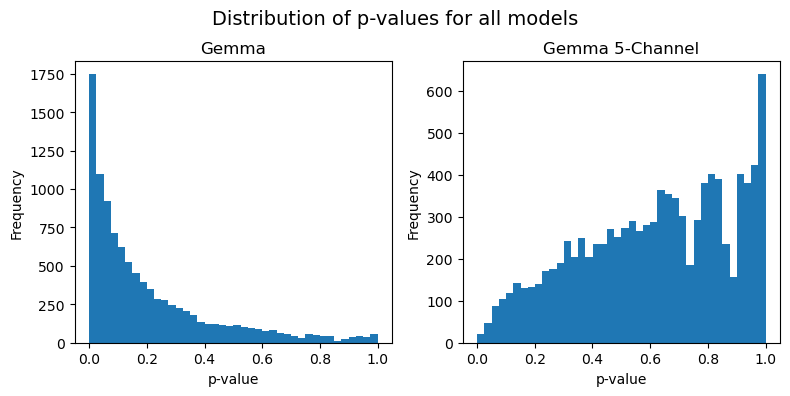

In [29]:
# Plot the distribution of p-values for all models. 
fig, axes = plt.subplots(1, 2, figsize = (8, 4))
fig.suptitle('Distribution of p-values for all models', fontsize = 14)

# Iterate through all models. 
for model_index, model_name in enumerate(model_names):
    ax = axes[model_index]
    ax.hist(dict_mcnemars_p_values[model_name], bins = 40)
    ax.set_title(model_name)
    ax.set_xlabel('p-value')
    ax.set_ylabel('Frequency')

# Adjust the layout of the subplots. 
plt.tight_layout()
plt.subplots_adjust(top = 0.85)

In [30]:
# Store the general results in a dictionary. 
general_results = dict()
general_results['df_summary_foundation_models'] = df_summary_foundation_models
general_results['df_summary_wilcoxon_multi_channel'] = df_summary_wilcoxon_multi_channel
general_results['df_summary_mcnemar_multi_channel'] = df_summary_mcnemar_multi_channel
general_results['df_summary_mcnemars'] = df_summary_mcnemars
general_results['dict_mcnemars_p_values'] = dict_mcnemars_p_values
general_results['df_flops_foundation_models'] = df_flops_foundation_models

# Save the general results into a Pickle file. 
with open(results_path + 'multi-channel/general_results.p', 'wb') as file:
    pickle.dump(general_results, file)